# Initialization

PorePy offers different approaches for initializing a simulation:
- explicit initial conditions
- implicit initial conditions (steady state and complying with the governing equations and boundary conditions at initial time)

In this tutorial, we demonstrate these options using a two-dimensional poroelastic fractured medium. The baseline poromechanics model is extended with appropriate geometry and boundary conditions representing typical lithostatic stress and hydrostatic pressure under active gravity. This example builds on a similar fractured medium as presented in the [single phase flow tutorial](single_phase_flow.ipynb). Physics are extended to cover both flow and deformation. Relevant material parameters as well as hydrostatic pressure and lithostatic stress boundary conditions corresponding to a depth of 1 km below the surface are applied to emulate more realistic subsurface conditions.

## Setting up a simulation with explicit initial conditions

PorePy models provide direct access to the initialization of all primary variables. For example, pressure can be initialized through `ic_values_pressure`, as defined below in `InitialConditionHydrostaticPressureValues`. If not explicitly specified, default values are used; in this example, zero displacement is assigned as the initial condition.

We construct the model described above and visualize the resulting initial state.

In [ ]:
# Model definition.
from typing import Callable
import porepy as pp
import numpy as np
from porepy.applications.md_grids.domains import nd_cube_domain
from porepy.applications.material_values.fluid_values import (
    extended_water_values_for_testing as water,
)
from porepy.applications.material_values.solid_values import (
    extended_granite_values_for_testing as granite,
)
from porepy.applications.boundary_conditions.model_boundary_conditions import (
    BoundaryConditionsMechanicsNeumann,
    LithostaticBoundaryStressValues,
    HydrostaticBoundaryPressureValues,
)
from porepy.applications.initial_conditions.model_initial_conditions import (
    InitialConditionHydrostaticPressureValues,
)
# from porepy.models.contact_mechanics import RadialReturnTangentialContactMechanicsEquation

# Set up logging (uncomment to see info messages from the solver)
# Uncomment for debugging purposes. Note that this will produce a lot of output.
# import logging
# logging.basicConfig(level=logging.INFO)

# --- Geometry modification ---
class ModifiedGeometry:
    """Simple 2D square domain with a single diagonal fracture."""

    def set_domain(self) -> None:
        # Define 2D square domain of size 100 m x 100 m and put it 1000 m below surface.
        size = self.units.convert_units(100., "m")
        self._domain = nd_cube_domain(2, size)

    def set_fractures(self) -> None:
        # Add diagonal fracture
        frac_1_points = self.units.convert_units(
            np.array([[40., 60.], [40., 60.]]), "m"
        )
        frac_1 = pp.LineFracture(frac_1_points)
        self._fractures = [frac_1]

    def grid_type(self) -> str:
        # Use simplex grid (non-Cartesian due to fracture)
        return "simplex"

    def meshing_arguments(self) -> dict:
        # Set mesh cell size
        cell_size = self.units.convert_units(10, "m")
        return {"cell_size": cell_size}


# --- Hydrostatic initial and boundary conditions ---

# TODO: Integrate in the core module and extend to cover 2D and 3D?
    
class BoundaryConditionsMechanicsNeumann2D(BoundaryConditionsMechanicsNeumann):
    """Two-dimensional variant of BoundaryConditionsMechanicsNeumann.
    
    Boundary conditions for the mechanics with Neumann conditions on almost all
    boundaries.

    The only exception is that internal boundaries are converted to Dirichlet and three
    points are partly fixed to avoid rigid body motions.
    
    We pick the following points:
            1) min x and mean y coordinate, (fixed in y direction)
            2) max x and mean y coordinate, (fixed in y direction)
            3) mean x and min y coordinate. (fixed in x direction)

    """

    domain: pp.domain.Domain
    """Model domain."""
    domain_boundary_sides: Callable[[pp.Grid | pp.BoundaryGrid], pp.domain.DomainSides]
    """Function returning the domain boundary sides of a given grid."""
    nd: int
    """Number of spatial dimensions."""

    def bc_type_mechanics(self, sd: pp.Grid) -> pp.BoundaryConditionVectorial:
        """Boundary condition type for mechanics.

        Neumann boundary conditions are defined on all boundaries.

        Parameters:
            sd: Subdomain for which to define boundary conditions.

        Returns:
            bc: Boundary condition object.

        """
        domain_sides = self.domain_boundary_sides(sd)
        bc = pp.BoundaryConditionVectorial(sd, domain_sides.all_bf, "neu")
        if sd.dim < self.nd:
            # No displacement is implemented on grids of co-dimension >= 1.
            return bc
        bc.internal_to_dirichlet(sd)
        faces_to_fix = self.faces_to_fix(sd)
        # Fix y displacements on face 1 & 3, x displacements on face 2.
        dir = [
            np.array([False, True]),  # Fix y on face 1 (west)
            np.array([True, False]),  # Fix x on face 2 (south)
            np.array([False, True]),  # Fix y on face 3 (east)
        ]
        for i, face in enumerate(faces_to_fix):
            bc.is_dir[:, face] = dir[i]
            bc.is_neu[:, face] = ~dir[i]  # Negate for Neumann
        return bc

    def faces_to_fix(self, sd: pp.Grid) -> list[np.int64]:
        """Return list of faces to fix to avoid rigid body motions.

        See class documentation for more details on the choice of points.

        Parameters:
            sd: Subdomain for which to define boundary conditions.

        Returns:
            List of face indices to fix, ordered as in the class documentation.

        """
        domain_sides = self.domain_boundary_sides(sd)
        box = self.domain.bounding_box

        # Mean x and y coordinates.
        x_mean = 0.5 * (box["xmax"] + box["xmin"])
        y_mean = 0.5 * (box["ymax"] + box["ymin"])

        # Point 1: center on west boundary.
        point_1 = np.array([box["xmin"], y_mean])
        pts = sd.face_centers[:2, domain_sides.west]
        ind_1 = domain_sides.west.nonzero()[0][
            np.argmin(pp.distances.point_pointset(point_1, pts))
        ]

        # Point 2: center of the south boundary.
        point_2 = np.array([x_mean, box["ymin"]])
        pts = sd.face_centers[:2, domain_sides.south]
        ind_2 = domain_sides.south.nonzero()[0][
            np.argmin(pp.distances.point_pointset(point_2, pts))
        ]

        # Point 3: center of the east boundary.
        point_3 = np.array([box["xmax"], y_mean])
        pts = sd.face_centers[:2, domain_sides.east]
        ind_3 = domain_sides.east.nonzero()[0][
            np.argmin(pp.distances.point_pointset(point_3, pts))
        ]

        indices = [ind_1, ind_2, ind_3]

        return indices
    

class LithostaticBoundaryStressValues2D(LithostaticBoundaryStressValues):
    """Two-dimensional variant of LithostaticBoundaryStressValues.
    
    Boundary conditions for the mechanics with lithostatic stress on all boundaries.

    Neumann boundary conditions are defined on all boundaries. Zero stress is assumed at
    time zero. This corresponds to an initial stress-free state, and presumably to zero
    initial displacement as well. For positive times, lithostatic stress is applied
    according to the depth of the boundary faces. The principal stresses are assumed to
    align with the coordinate axes, and the relative magnitudes can be adjusted through
    the parameter "lithostatic_stress_multipliers", which should be an array of three
    values. The default is an array of ones, corresponding to equal stresses in all
    directions.

    """

    params: dict
    """Model parameters."""
    depth: Callable[[np.ndarray], np.ndarray]
    """Function to compute depth of points."""
    equation_system: pp.EquationSystem
    """Equation system associated with the model."""
    gravity_force: Callable[[pp.GridLikeSequence], pp.ad.Operator]
    """Function to compute gravity force."""
    domain_boundary_sides: Callable[[pp.GridLike], pp.domain.DomainSides]
    """Function returning the domain boundary sides of a given grid."""
    time_manager: pp.TimeManager
    """Time manager associated with the model."""


    def bc_values_stress(self, boundary_grid: pp.BoundaryGrid) -> np.ndarray:
        """Stress values.

        Parameters:
            boundary_grid: Boundary grid for which boundary values are to be returned.

        Returns:
            Array of boundary values, with one value for each dimension of the
                problem, for each face in the subdomain.

        """
        # Assume zero initial stress state.
        if (
            self.time_manager.time
            < self.time_manager.time_init + 0.5 * self.time_manager.dt_min_max[0]
        ):
            # Identify dimension of the problem from the lithostatic stress multipliers.
            dim = len(self.lithostatic_stress_multipliers)
            # Initialize array for stress values.
            values = np.zeros((dim, boundary_grid.num_cells))
            return values.ravel("F")
        else:
            return self.active_bc_values_stress(boundary_grid)

    def active_bc_values_stress(self, boundary_grid: pp.BoundaryGrid) -> np.ndarray:
        """Stress values.

        Parameters:
            boundary_grid: Boundary grid for which boundary values are to be returned.

        Returns:
            Array of boundary values, with one value for each dimension of the
                problem, for each face in the subdomain.

        """
        # Identify dimension of the problem from the lithostatic stress multipliers.
        dim = len(self.lithostatic_stress_multipliers)

        # Initialize array for stress values.
        values = np.zeros((dim, boundary_grid.num_cells))

        gravity = self.gravity_force_magnitude("bulk")
        # Multiply with lithostatic stress multipliers, which can be used to set
        # different stresses in different directions.
        gradient = self.lithostatic_stress_multipliers * gravity
        # Allow for explicit offset (typically lithostatic stress multiplier times
        # effective overburden stress at surface of the domain).
        offset = self.lithostatic_stress_offset
        # Get domain sides and depth at boundary cell centers.
        domain_sides = self.domain_boundary_sides(boundary_grid)
        depth = self.depth(boundary_grid.cell_centers)

        # The sign of the stress depends on the side of the domain according to the
        # direction of the outer normal vector on the boundary. Loop over directions.
        for i, sides in enumerate(
            [["west", "east"], ["south", "north"]]
        ):
            # Apply stress on both sides of the domain in direction i.
            for side, sign in zip(sides, [1, -1]):
                # Get indices of faces on the given side.
                ind = getattr(domain_sides, side)
                if np.any(ind):
                    # Set ith component of stress on these faces.
                    values[i, ind] = (
                        (offset[i] + gradient[i] * depth[ind])
                        * sign
                        * boundary_grid.cell_volumes[ind]
                    )

        return values.ravel("F")
            

class MatplotlibExporting:
    """Auxiliary class to enable visualization in this notebook."""

    # --- Auxiliary plotting function ---
    @staticmethod
    def plot_model(model: pp.SolutionStrategy) -> None:
        """Plot pressure and displacement distribution of the model."""
        pp.plot_grid(
            model.mdg,
            cell_value=model.pressure_variable,
            vector_value=model.displacement_variable,
            figsize=(10, 8),
            linewidth=0.25,
            title=(
                """Pressure and displacement distribution at """
                f"""time {model.time_manager.time//3600} hrs"""
            ),
            plot_2d=True,
            color_map_limits=[0, 0.00012]
        )

    def after_time_step_convergence(self) -> None:
        """Export results after each time step convergence."""
        MatplotlibExporting.plot_model(self)
        super().after_time_step_convergence()

class Model(
    # Our fractured domain
    ModifiedGeometry,
    # Initial conditions for flow
    InitialConditionHydrostaticPressureValues,
    # Boundary conditions for flow
    # Boundary conditions for mechanics
    BoundaryConditionsMechanicsNeumann2D, 
    LithostaticBoundaryStressValues2D,
    MatplotlibExporting,
    # Base model
    # RadialReturnTangentialContactMechanicsEquation,
    pp.applications.boundary_conditions.HydrostaticBoundaryPressureValues,
    pp.constitutive_laws.CharacteristicDisplacementFromTraction,
    pp.constitutive_laws.GravityForce,
    pp.constitutive_laws.CubicLawPermeability,
    pp.Poromechanics,
):
    ...

# --- Material properties (fetch realistic values) ---
fluid_constants = pp.FluidComponent(**water)
solid_constants = pp.SolidConstants(**granite)
numerical_constants = pp.NumericalConstants(**{"characteristic_contact_traction": 10 * 3000 * 9.81})
material_constants = {
    "fluid": fluid_constants,
    "solid": solid_constants,
    "numerical": numerical_constants,

}

# --- Time stepping (single short time step) ---
time_manager = pp.TimeManager(
    schedule=[0, 5 * 1000 * pp.YEAR],
    dt_init=1000 * pp.YEAR,
    constant_dt=True,
    iter_max=10,
    print_info=True,
)

# --- Units for scaling ---
units = pp.Units(kg=1e10) # Avoid numerical issues by scaling units.

# --- Summarize model parameters ---

# Apply 80% horizontal stress and 100% vertical stress, corresponding to a normal
# faulting regime. Define offsets corresponding to a domain that is 1000 m below
# the surface.
depth = 1000  # Depth in meters
rho_fluid = 1000  # Fluid density in kg/m^3
rho_bulk = 2500  # Bulk density in kg/m^3
hydrostatic_pressure_offset = depth * rho_fluid * 9.81
lithostatic_stress_multipliers = np.array([0.8, 1])
lithostatic_stress_offset = depth * rho_bulk * 9.81 * lithostatic_stress_multipliers

model_params = {
    "material_constants": material_constants,
    "time_manager": time_manager,
    "units": units,
    "hydrostatic_pressure_datum": hydrostatic_pressure_offset,
    "lithostatic_stress_offset": lithostatic_stress_offset,
    "lithostatic_stress_multipliers": lithostatic_stress_multipliers,
}

C:\Users\jbo062\src\porepy\src\porepy\utils\ui_and_logging.py:45: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm as progressbar_class  # type: ignore


Let's define a model and just call the internal method `prepare_simulation`, which sets the explicits initial conditions as the solution at initial time. We visualize the (hydrostatic) pressure and (zero) displacement. 

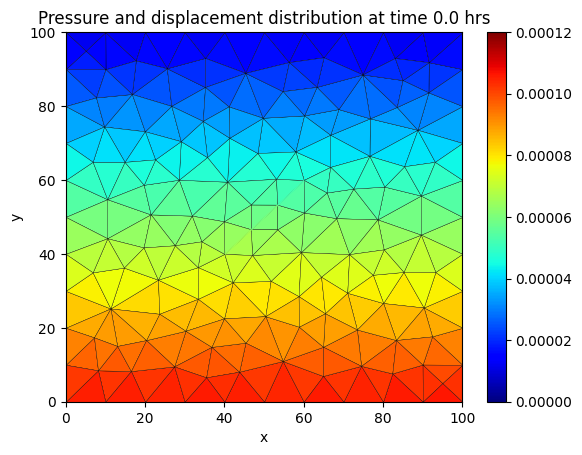

In [2]:
# --- Create model instance and plot initial conditions ---
model_with_explicit_initialization = Model(model_params)
model_with_explicit_initialization.prepare_simulation()
MatplotlibExporting.plot_model(model_with_explicit_initialization)

### Necessity for complying boundary and initial conditions
Depending on the model choice, when setting explicit initial conditions, there is a need for defining complying boundary conditions due to the fact that PorePy employs a finite volume method. The porosity of a deformable medium includes the divergence of the displacement, which effectively integrates boundary conditions for stresses and displacements. If not set in a complying sense, there is an inconsistency in the time derivative corrupting the dynamics. 

In the above example, zero initial conditions are used for the displacement by default. These comply with zero effective stress (the full stress includes also the pressure contribution). Therefore, the correct initial boundary conditions for the stress are zero as well and instantly for time > 0, they are activated, as seen in the function `bc_values_stress`. This induces stress on the medium and therefore contributing to the displacement.

**NOTE:** When computing the steady state, this inconcistency is not relevant.

### Computing a steady state
We now run the model with large time steps to approximate steady-state conditions that satisfy the governing equations and boundary conditions. The resulting pressure field closely matches the prescribed boundary values, while also yielding a corresponding displacement field that is in mechanical equilibrium with the pressure distribution. We note the need for running multiple time steps with very large time step size. Using only a single time step displays the incompatiblilty of the user-defined initial conditions with the boundary conditions and governing equation under steady state conditions.

**NOTE**. We observe that the pressure field does, in fact, evolve over time. This behavior arises from the initially non-equilibrated displacement field, the poromechanical coupling, and the (small but non-zero) compressibility, all of which contribute to transient pressure changes. 

**Tip**. The large time step size is important here to quickly obtain a steady state. Change the definition of the `time_manager` above to investigate short time steps.

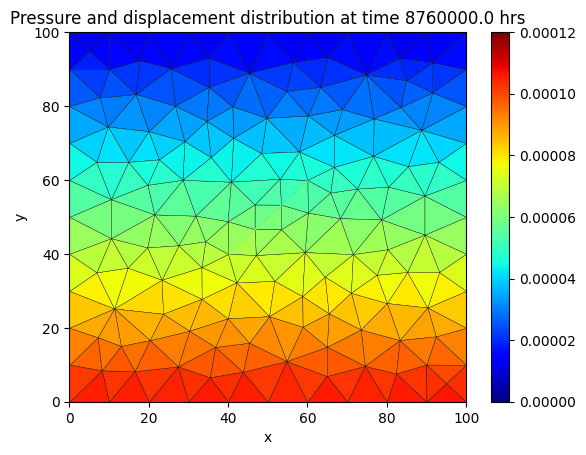

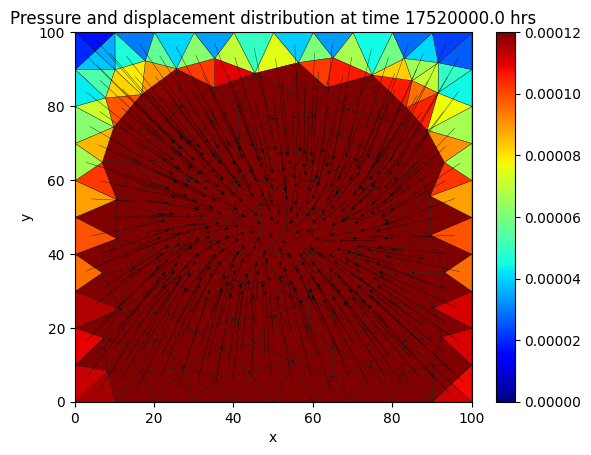

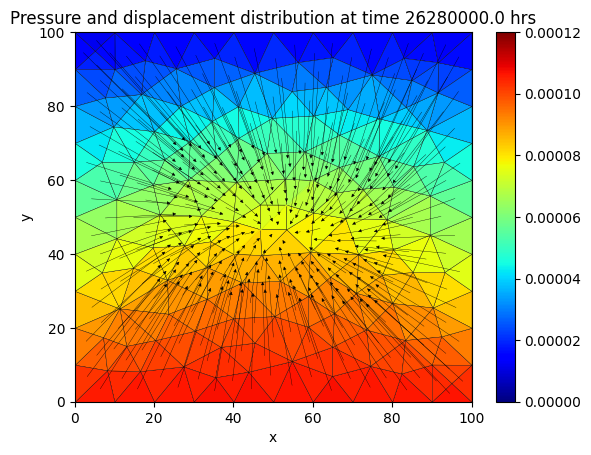

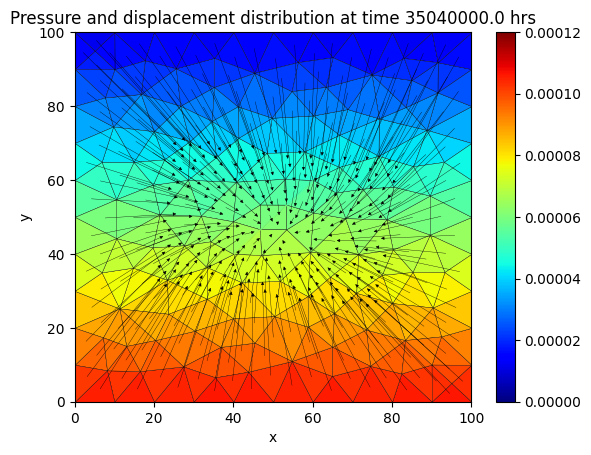

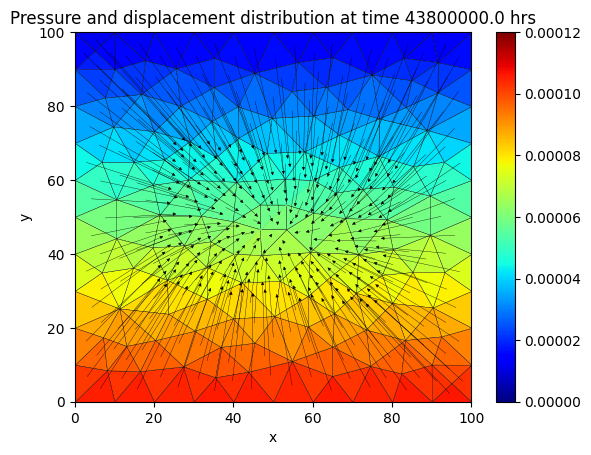

In [3]:
# --- Solver parameters for controlling convergence ---
 
solver_params = {
    "nl_convergence_criteria": {
        "inc_rel": pp.IncrementBasedRelativeCriterion(
            tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_explicit_initialization)
        ),
        "res_rel": pp.ResidualBasedRelativeCriterion(
            tol=1e-6, metric=pp.EquationBasedEuclideanMetric(model_with_explicit_initialization)
        ),
    },
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
    },
}
solver_params_without_prepare = solver_params.copy()
solver_params_without_prepare["prepare_simulation"] = False

# --- Run simulation and plot results ---
pp.ModelRunner(model_with_explicit_initialization, solver_params_without_prepare).run()

## Implicit steady-state initial conditions
Initializing a simulation for relevant conditions, typically means finding equilibrium conditions. This requires finding complying conditions to governing equations and boundary conditions by solving the problem until steady state just as above. 

PorePy offers the possibility to run such a simulation as initialization, yet without interfering with the time manager and thus allowing for seemless transition to an actual dynamic simulation. To demonstrate this below, we redefine the model to apply all initial boundary conditions also at initial time, and to include dyanmics, here controlled by a time-dependent source term and not active yet at initial time (and thus later not influencing the steady-state).

In [4]:
class InstantantBoundaryConditionsMechanicsNeumann2D(BoundaryConditionsMechanicsNeumann2D):
    """Same as BoundaryConditionsMechanicsNeumann2D, but with instant activation of
    stress boundary conditions."""

    def bc_values_stress(self, boundary_grid: pp.BoundaryGrid) -> np.ndarray:
        """Stress values.

        Parameters:
            boundary_grid: Boundary grid for which boundary values are to be returned.

        Returns:
            Array of boundary values, with one value for each dimension of the
                problem, for each face in the subdomain.

        """
        return self.active_bc_values_stress(boundary_grid)
    
class ModifiedSource(pp.fluid_mass_balance.FluidMassBalanceEquations):
    """Simple fluid source in the fracture for time > 0."""

    def fluid_source(self, subdomains: list[pp.Grid]) -> pp.ad.Operator:
        """Assign unitary fracture source"""
        # Retrieve internal sources (jump in mortar fluxes) from the base class
        internal_sources: pp.ad.Operator = super().fluid_source(subdomains)

        # External sources are retrieved from SOLUTIONS and wrapped as an AdArray.
        external_sources = pp.ad.TimeDependentDenseArray(
            name="external_sources",
            domains=self.mdg.subdomains(),
        )

        # Add up contributions.
        fluid_source = internal_sources + external_sources
        fluid_source.set_name("Time-dependent fluid source")

        return fluid_source

    def fluid_source_array(self, sd: pp.Grid, time: float) -> list[np.ndarray]:
        """Assign unitary fracture source, only after initialization."""
        if time > pp.SECOND and sd.dim == 1:
            return self.units.convert_units(1e-2 * np.ones(sd.num_cells), "kg * s^-1")
        else:
            return np.zeros(sd.num_cells)
        
    
    def update_time_dependent_ad_arrays(self) -> None:
        """Update values of external sources and boundary conditions."""
        super().update_time_dependent_ad_arrays()

        for sd, data in self.mdg.subdomains(return_data=True):
            pp.set_solution_values(
                name="external_sources",
                values=self.fluid_source_array(sd, self.time_manager.time),
                data=data,
                time_step_index=0,
            )
            pp.set_solution_values(
                name="external_sources",
                values=self.fluid_source_array(sd, self.time_manager.time),
                data=data,
                iterate_index=0,
            )

# --- Dynamic model ---

class DynamicModel(InstantantBoundaryConditionsMechanicsNeumann2D, ModifiedSource, Model):
    ...



We redefine the time manager aiming at capturing the early dynamics of the fracture stimulation.

In [5]:
# ---- Redefine the time manager to use shorter time steps typically used for dynamics simulation ----
model_params_for_initialization = model_params.copy()
model_params_for_initialization["time_manager"] = pp.TimeManager(
    schedule=[0, 24 * pp.HOUR],
    dt_init= 1 * pp.HOUR,
    dt_min_max=(pp.MINUTE, 10 * pp.HOUR),
    constant_dt=False,
    iter_max=25,
    print_info=True,
    iter_optimal_range=(7, 10),
)

# --- Create model instance ---
model_with_implicit_initialization = DynamicModel(model_params_for_initialization)

To better demonstrate the transition towards a dynamic setting, we extend the above setting to include a fracture source just as in the [single phase flow tutorial](single_phase_flow.ipynb). 

In [6]:
# --- Solver parameters for initialization ---

from porepy.numerics.nonlinear.convergence_check import (
    ConvergenceCriteria,
    DivergenceCriteria,
)

# Define solver parameters for initialization, including convergence and divergence criteria.
solver_params_for_initialization = {
    # Standard convergence criteria for the nonlinear solver.
    "nl_convergence_criteria": {
        "inc_rel": pp.IncrementBasedRelativeCriterion(
            tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
        ),
        "res_rel": pp.ResidualBasedRelativeCriterion(
            tol=1e-6, metric=pp.EquationBasedEuclideanMetric(model_with_implicit_initialization)
        ),
    },
    # Divergence criteria for the nonlinear solver.
    "nl_divergence_criteria": {
        "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
        "inc_nan": pp.IncrementBasedNanCriterion(),
        "res_nan": pp.ResidualBasedNanCriterion(),
    },
    # Initialization parameters for the model.
    "initialization": {
        # Define initialization mode and convergence/divergence criteria for steady-state initialization.
        "mode": "steady-state",
        # Convergence criteria for characterizing steady-states (same API as for the nonlinear solver).
        "steady_state_convergence_criteria": ConvergenceCriteria({
            "inc_rel": pp.IncrementBasedRelativeCriterion(
                tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
            ),
            "inc_abs": pp.IncrementBasedAbsoluteCriterion(
                tol=1e-6, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
            ),
        }),
        # Divergence criteria for characterizing steady-states (same API as for the nonlinear solver).
        "steady_state_divergence_criteria": DivergenceCriteria({
            "max_iter": pp.MaxIterationsCriterion(max_iterations=25),
            "inc_nan": pp.IncrementBasedNanCriterion(),
            "inc_abs": pp.IncrementBasedAbsoluteCriterion(
                tol=1e10, metric=pp.VariableBasedEuclideanMetric(model_with_implicit_initialization)
            ),       
        }),
        # Define pseudo time stepping parameters for the initialization process.
        # NOTE: Non-constant dt is always used to accelerate convergence to steady-state.
        "pseudo_dt_init": 1000 * pp.YEAR,
        "pseudo_dt_max": 100000 * pp.YEAR,
    }
}


We are now ready to perform the initialization. This step is handled at the `ModelRunner` level. Before starting a simulation using the `run` method - which triggers the time loop - we must first call the `initialize` method. This ensures that the model starts from the same initial conditions as those obtained by running a simulation to steady state, as described above. However, the time manager is still reset to time `t=0`. After initialization, we proceed with the dynamic fracture stimulation starting from the steady state, which uses the previously defined time discretization settings with short time steps.

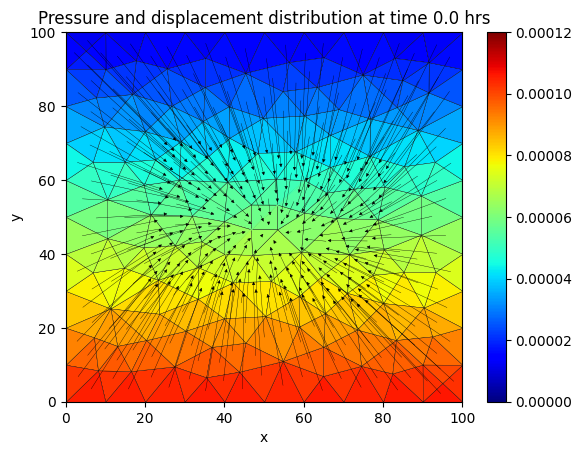

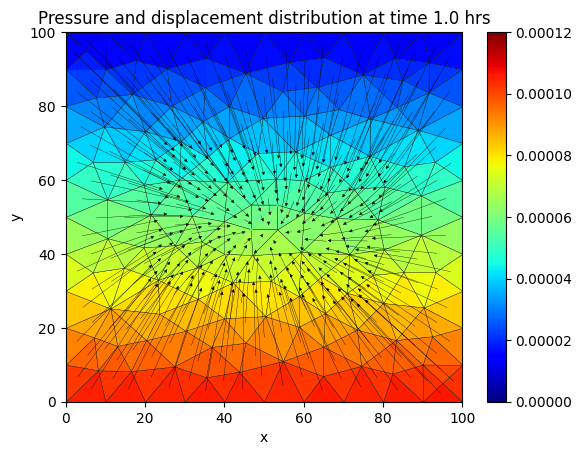

Restricting time step. Next dt = 2520.0.


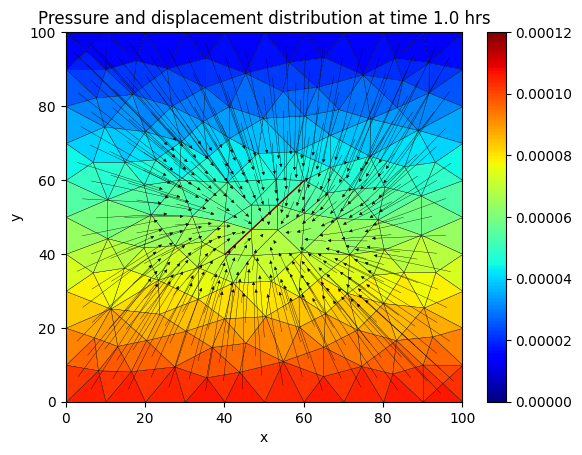

Relaxing time step. Next dt = 3276.0.


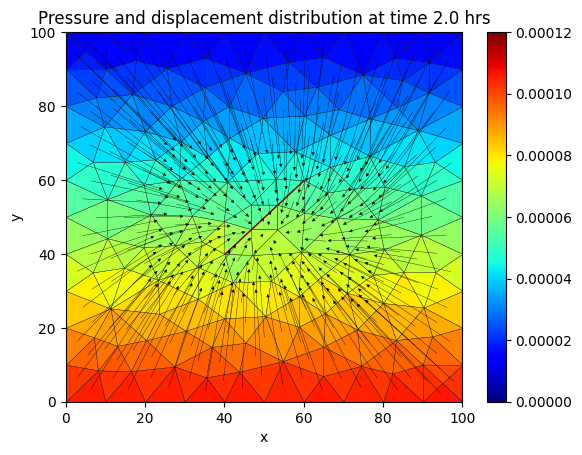

Relaxing time step. Next dt = 4258.8.


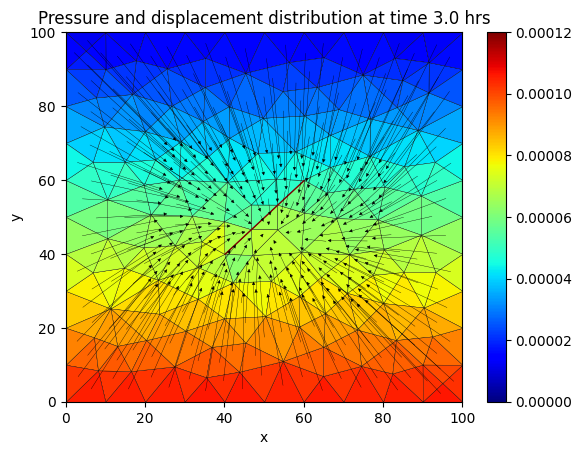

Relaxing time step. Next dt = 5536.4400000000005.


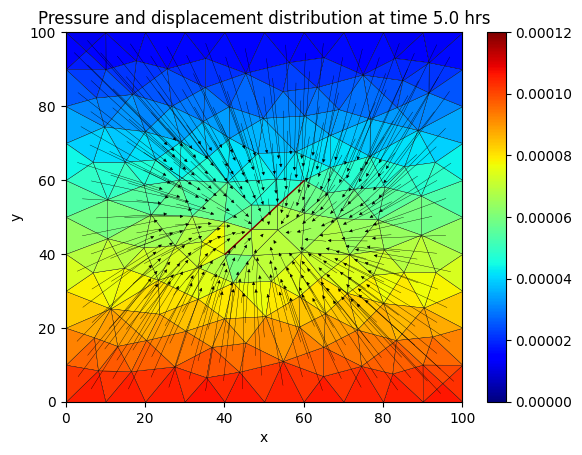

Relaxing time step. Next dt = 7197.372000000001.


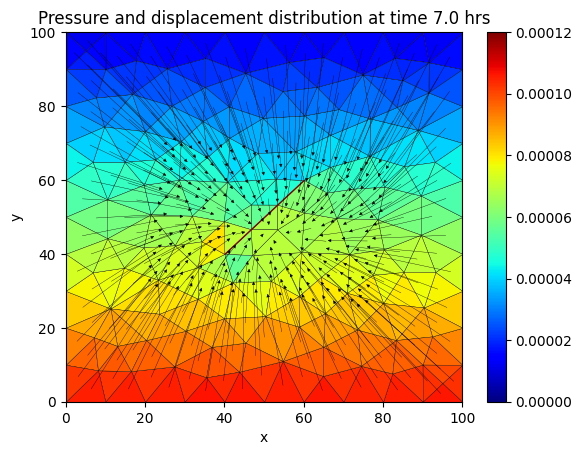

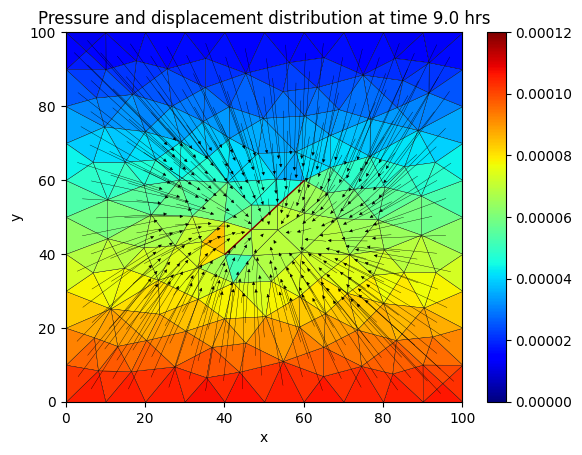

Relaxing time step. Next dt = 9356.583600000002.


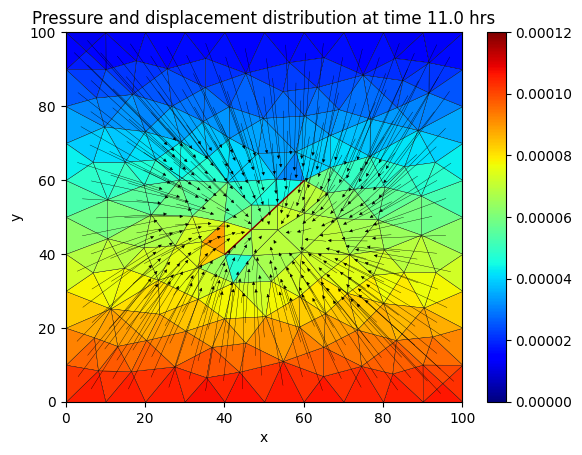

Relaxing time step. Next dt = 12163.558680000002.


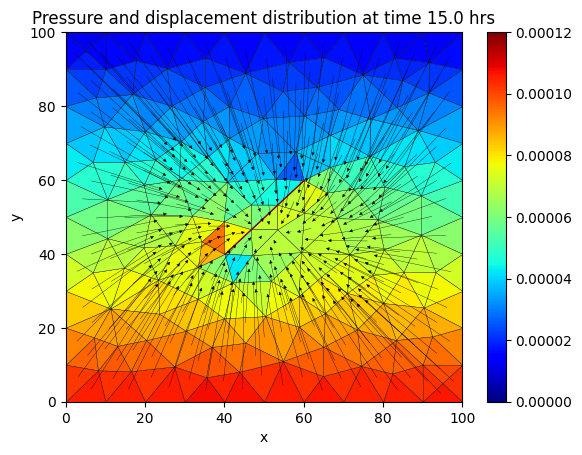

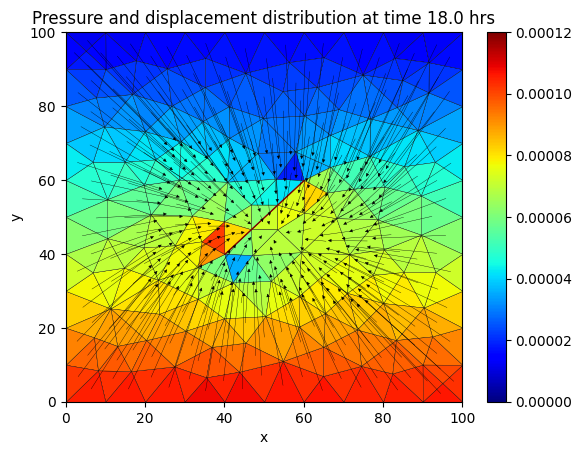

Relaxing time step. Next dt = 15812.626284000004.


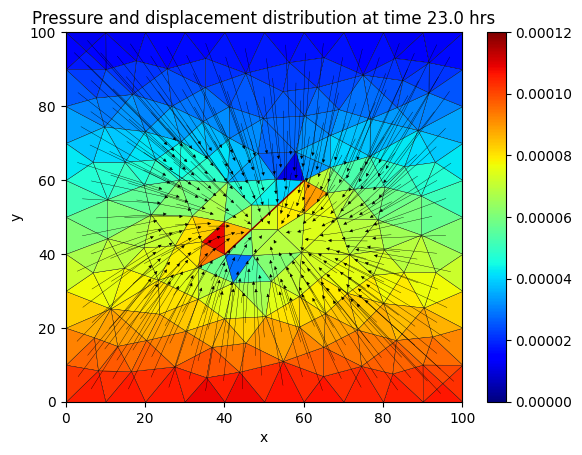

Relaxing time step. Next dt = 20556.414169200005.
Correcting time step to match final time. Final dt = 3317.6887559999886.


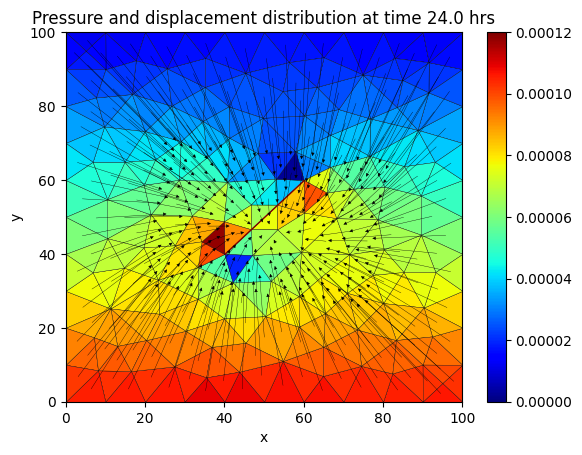

In [7]:
runner = pp.ModelRunner(model_with_implicit_initialization, solver_params_for_initialization)
runner.initialize()
MatplotlibExporting.plot_model(model_with_implicit_initialization)
runner.run()
